In [3]:
import json

In [4]:
# BENCH_NAME = "liar-raw-cv-test" 
# BENCH_NAME = "liar-raw-cv-train" 
BENCH_NAME = "raw-fc-cv-test"
# BENCH_NAME = "raw-fc-cv-train"
# BENCH_NAME = "averitec-cev-dev" 
# BENCH_NAME = "averitec-cev-train"

TEST_SET_PATH = "/home/comp/24483737/fc/data/rawfc-post/small-original-half/test_rawfc_cv.json"
# TEST_SET_PATH = "/home/comp/24483737/fc/data/rawfc-post/small-original-half/train_rawfc_cv.json"
# TEST_SET_PATH = "/home/comp/24483737/fc/data/liar-raw-post/not_ordinal/test_liar_raw_cv.json"
# TEST_SET_PATH = "/home/comp/24483737/fc/data/liar-raw-post/not_ordinal/train_liar_raw_cv.json"
# TEST_SET_PATH = "/home/comp/24483737/fc/data/post-averitec/lalast/dev_averitec_cev_remove.json"
# TEST_SET_PATH = "/home/comp/24483737/fc/data/post-averitec/last/train_averitec_cev.json"
PAIRS = "cvi-cvi"
MODEL_NAME = "llama-2-rawfc-cross-raw-cvi-cvi-infer-lr-la10-m1.5"

FAST_CHAT_FORMAT = f"/home/comp/24483737/FastChat/fastchat/llm_judge/data/{BENCH_NAME}/model_answer/{PAIRS}/{MODEL_NAME}.jsonl"

In [5]:
def read_json_object(file_path):
    with open(file_path, 'r', encoding="utf-8") as file:
        json_data = json.load(file)
    return json_data

def read_single_line(file_path):
    with open(file_path, 'r', encoding="utf-8") as file:
        session_list = file.readlines()
    new_list = []
    for session_str in session_list:
        new_list.append(eval(session_str))
    return new_list

In [6]:
import re

In [7]:
def combine(predicted_path, grouth_truth_path):
    predicted_list = read_single_line(predicted_path)
    gt_list = read_json_object(grouth_truth_path)

    predicted_dict = {item['question_id']: item['choices'][0]['turns'][0] for item in predicted_list}

    result = []
    
    for item in gt_list:
        base_id = item['id']
        predicted_text = predicted_dict[base_id]
        match = re.search(r"(true|false|half)\.?\s*Explanation:", predicted_text)
        # match = re.search(r"(TRUE|FALSE|HALF-TRUE)\.?\s*Explanation:", predicted_text)
        # match = re.search(r"(Supported|Refuted|Not Enough Evidence)\.?\s*Explanation:", predicted_text)
        if match:
            label_str = match.group(1) 
        else:
            label_str = predicted_text

        if base_id in predicted_dict:
            for turn in item ['conversations']:
                if turn['from'] == 'gpt':
                    label = turn['value'].split(':')[-1].strip()
                    if label == 'TRUE':
                        label_wuyu = 'true'
                    elif label == 'HALF-TRUE':
                        label_wuyu = 'half'
                    else:
                        label_wuyu = 'false'
            combined = {
                'id': item['id'],
                'question_id': base_id,
                'label': label,
                # 'label': label_wuyu,
                'predicted': label_str,
            }
            result.append(combined)
    
    return result

In [8]:
res = combine(FAST_CHAT_FORMAT, TEST_SET_PATH)

In [9]:
len(res)

200

In [10]:
res[0]

{'id': '101929', 'question_id': '101929', 'label': 'half', 'predicted': 'half'}

In [11]:
if "averitec" in MODEL_NAME:
    filtered = read_json_object("/home/comp/24483737/fc/data/post-averitec/final_2802_nolabelerror/filtered_train_averitec_cevi_ordinal.json")
    filtered_id = [_['id'] for _ in filtered]
    filtered_res = []
    for sample in res:
        if sample['id'] in filtered_id:
            continue
        filtered_res.append(sample)
    print(len(filtered_res))

In [12]:
res[14]

{'id': '142961',
 'question_id': '142961',
 'label': 'half',
 'predicted': 'false'}

In [13]:
cnt = dict()
for exp in res:
    cnt[exp['predicted']] =  cnt.get(exp['predicted'], 0) + 1 

In [14]:
cnt

{'half': 66, 'false': 63, 'true': 71}

In [15]:
cor = 0
for item in res:
    if item['label']==item['predicted']:
        cor += 1
print(cor)

130


In [16]:
cor / len(res)

0.65

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

if "averitec" in BENCH_NAME:
    y_true = [sample['label'] for sample in filtered_res]
    y_pred = [sample['predicted'] for sample in filtered_res]
    ids = [sample['id'] for sample in filtered_res]  
else:
    y_true = [sample['label'] for sample in res]
    y_pred = [sample['predicted'] for sample in res]
    ids = [sample['id'] for sample in res]  

if "liar-raw" in BENCH_NAME:
    classes = ['TRUE', 'FALSE', 'HALF-TRUE']  
elif "raw-fc" in BENCH_NAME:
    classes = ['true', 'false', 'half']  
elif "averitec" in BENCH_NAME:
    classes = ['Supported', 'Refuted', 'Not Enough Evidence']
    
valid_classes = set(classes)

filtered = []
dropped = []  

for id_, yt, yp in zip(ids, y_true, y_pred):
    if yt in valid_classes and yp in valid_classes:
        filtered.append((yt, yp))
    else:
        dropped.append((id_, yt, yp))

if filtered:
    y_true_filtered, y_pred_filtered = zip(*filtered)
else:
    y_true_filtered, y_pred_filtered = [], []

print("⚠️ Filtered Invalid samples：")
for id_, yt, yp in dropped:
    print(f"id: {id_}, y_true: '{yt}', y_pred: '{yp}'")


⚠️ Filtered Invalid samples：


In [18]:
len(dropped)

0

Accuracy: 0.6500

Macro-F1: 0.6499

Macro-Precision: 0.6504

Macro-Recall: 0.6501

Per-class metrics:

Class: true
  Precision: 0.6620
  Recall: 0.7015
  F1: 0.6812

Class: false
  Precision: 0.6984
  Recall: 0.6667
  F1: 0.6822

Class: half
  Precision: 0.5909
  Recall: 0.5821
  F1: 0.5865


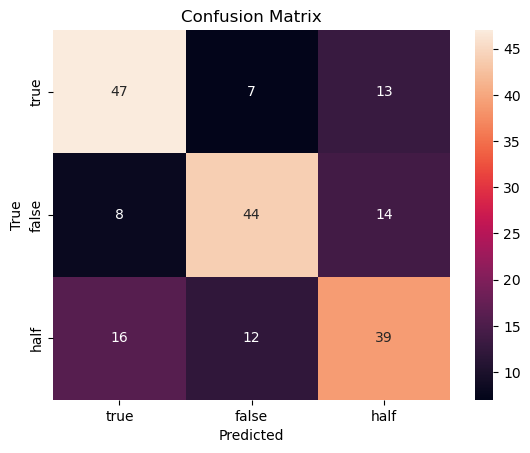

In [19]:
accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, labels=classes, average='macro')
precision_weighted = precision_score(y_true, y_pred, labels=classes, average='macro')
recall_weighted = recall_score(y_true, y_pred, labels=classes, average='macro')

print(f"Accuracy: {accuracy:.4f}")
print(f"\nMacro-F1: {macro_f1:.4f}")
print(f"\nMacro-Precision: {precision_weighted:.4f}")
print(f"\nMacro-Recall: {recall_weighted:.4f}")

print("\nPer-class metrics:")
for cls in classes:
    cls_f1 = f1_score(y_true, y_pred, labels=[cls], average='micro')  
    cls_precision = precision_score(y_true, y_pred, labels=[cls], average='micro')
    cls_recall = recall_score(y_true, y_pred, labels=[cls], average='micro')
    
    print(f"\nClass: {cls}")
    print(f"  Precision: {cls_precision:.4f}")
    print(f"  Recall: {cls_recall:.4f}")
    print(f"  F1: {cls_f1:.4f}")

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred, labels=classes)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
